<h1> EDA(Exploratory Data Analysis ) </h1>

모델링 파이프라인에서 전처리(Preprocessing) 이전에 연속형 수치 또는 범주형 데이터를 이해·분석하는 단계

<h4> 단일 컬럼 분석 (Univariate) </h4>

목적  
◾ 데이터 이해: 각 변수의 분포·범위·이상치 유무 파악  
◾ 전처리 방향: 치우침, 스케일 차이, 결측치 처리 전략 결정  
◾ 모델 가정 확인: 정규성·등분산성 등 가정 준수 여부 평가  

방법  
◾기본 통계량 확인  
    describe() 로 count, mean, std, min/max, 사분위수 확인  
    왜도(skew), 첨도(kurtosis) 계산으로 분포 형태 파악  

◾결측치·고유값 확인  
    isnull().sum() 으로 결측 개수 체크  
    value_counts() 로 범주별 빈도 확인  

◾분포 시각화  
    연속형: histplot, kdeplot, boxplot, violinplot  
    범주형: countplot, 막대그래프  

◾이상치 탐지  
    IQR 기반(boxplot) 혹은 σ 기준(±3σ)으로 극단값 파악  
    필요 시 제거·대체 여부 판단  

◾데이터 타입·단위 점검  
    숫자형인데 문자열로 저장된 값 없는지 확인  
    단위(원, %, kg 등)가 통일되었는지 점검  

◾변환 필요성 판단  
    심한 치우침(skew) 시 로그·Box–Cox 변환 고려  
    분포가 멀티모달일 땐 구간화(binning) 검토  
    

In [103]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

In [104]:
np.random.seed(42)

df = pd.DataFrame({
    'feature_numeric': np.random.normal(loc=50, scale=10, size=5),
    'num1': [1, 2, 3, 4, 5],
    'num2': [10.5, 7.2, 9.8, 2.1, 5.6],
    'city': ['Seoul', 'Gyeonggi', 'Gyeongsangbuk', 'Gyeonggi', 'Gwangju'],
    'color': pd.Categorical(['red', 'blue', 'green', 'red', 'blue'])
})

In [105]:
df

,feature_numeric,num1,num2,city,color
0,54.967142,1,10.5,Seoul,red
1,48.617357,2,7.2,Gyeonggi,blue
2,56.476885,3,9.8,Gyeongsangbuk,green
3,65.230299,4,2.1,Gyeonggi,red
4,47.658466,5,5.6,Gwangju,blue


In [106]:
num_cols = df.select_dtypes(include=['float', 'int']).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

1. 기본통계량 확인

count	유효(Non‑null) 관측치의 개수  
mean	산술평균: 데이터의 중심(central tendency)  
std	표본 표준편차(sample standard deviation): 분산 정도(퍼짐) 표시. 평균에서 데이터가 평균적으로 얼마나 떨어져 있는지(흩어짐 정도)
min / max	최솟값과 최댓값: 데이터 범위(range)의 양끝 

25%·50%·75%	각각 1·2·3사분위수(quartile): 정렬된 값들 사이의 위치값  

25% (1사분위): 아래 25% 지점 
50% (중앙값): 절반 지점  
75% (3사분위): 위 25% 지점  

In [107]:
def check_describe(column) :
    desc = df[column].describe()
    print("기본 통계량:\n", desc.to_string())

In [108]:
def check_skew(column) : 
    print(f"왜도(skew): {skew(df[column].dropna()):.2f}")

In [109]:
def check_kurtosis(column) : 
    print(f"첨도(kurtosis): {kurtosis(df[column].dropna(), fisher=False):.2f}")

In [110]:
def check_missing_values(column) :
    print(f"결측치 개수:", df[column].isnull().sum())

In [111]:
def get_unique_values_count(column) :
    return df[column].nunique(dropna=True)

In [112]:
def check_unique_values(column) : 
    unique_values_count = get_unique_values_count(column)
    print(f"고유값 개수: {unique_values_count}")
    
    if unique_values_count <= 10:
        print("→ 값 분포:\n", df[column].value_counts(dropna=False).sort_index())

In [113]:
def show_hist_kde_plot(column) :
    plt.figure(figsize=(6,2))
    sns.histplot(df[column], bins=30, kde=True)
    plt.title(f"{column} 분포(hist+KDE)")
    plt.show()

In [114]:
def show_box_plot(column) :
    plt.figure(figsize=(6,1.5))
    sns.boxplot(x=df[column], showfliers=True)
    plt.title(f"{column} Boxplot")
    plt.show()

In [115]:
def detect_outliers_by_IQR(column) :
    Q1, Q3 = df[column].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = df.loc[(df[column] < lower) | (df[column] > upper), column]
    print(f"이상치 개수: {len(outliers)}", 
          f"(범위 {lower:.2f} ~ {upper:.2f})")

In [116]:
def check_numberic_type_unit(column) :
    print(f"dtype: {df[column].dtype}")
    # 단위 추정 (컬럼명 뒤 _ 뒤 문자열)
    unit = column.split('_')[-1]
    print(f"추정 단위: {unit}")

In [117]:
def decide_trans_by_skew(column) :
    s = skew(df[column].dropna())
    if abs(s) >= 1.0:
        print(f"→ |skew|={abs(s):.2f} ≥ 1.0: 로그 변환 등 고려")
    else:
        print(f"→ |skew|={abs(s):.2f} < 1.0: 변환 불필요")


=== [Numeric] feature_numeric ===
기본 통계량:
 count     5.000000
mean     54.590030
std       7.082322
min      47.658466
25%      48.617357
50%      54.967142
75%      56.476885
max      65.230299
왜도(skew): 0.52
첨도(kurtosis): 2.04
결측치 개수: 0
고유값 개수: 5
→ 값 분포:
 feature_numeric
47.658466    1
48.617357    1
54.967142    1
56.476885    1
65.230299    1
Name: count, dtype: int64


f:\examination\workspace\associate.aice\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
f:\examination\workspace\associate.aice\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


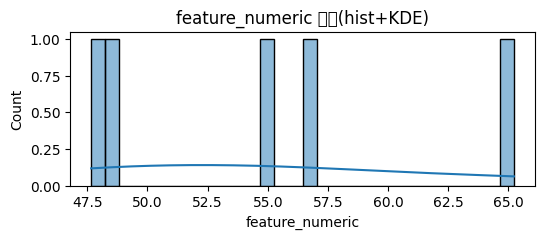

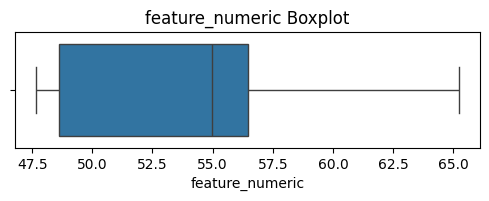

이상치 개수: 0 (범위 36.83 ~ 68.27)
dtype: float64
추정 단위: numeric
→ |skew|=0.52 < 1.0: 변환 불필요

=== [Numeric] num1 ===
기본 통계량:
 count    5.000000
mean     3.000000
std      1.581139
min      1.000000
25%      2.000000
50%      3.000000
75%      4.000000
max      5.000000
왜도(skew): 0.00
첨도(kurtosis): 1.70
결측치 개수: 0
고유값 개수: 5
→ 값 분포:
 num1
1    1
2    1
3    1
4    1
5    1
Name: count, dtype: int64


f:\examination\workspace\associate.aice\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
f:\examination\workspace\associate.aice\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


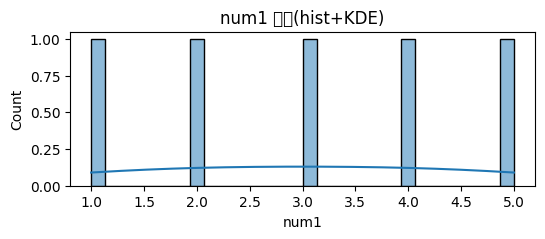

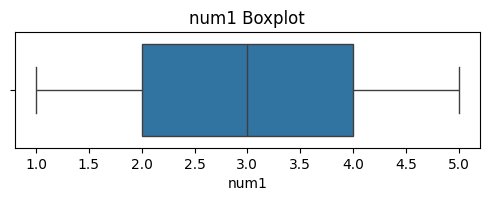

이상치 개수: 0 (범위 -1.00 ~ 7.00)
dtype: int64
추정 단위: num1
→ |skew|=0.00 < 1.0: 변환 불필요

=== [Numeric] num2 ===
기본 통계량:
 count     5.000000
mean      7.040000
std       3.394554
min       2.100000
25%       5.600000
50%       7.200000
75%       9.800000
max      10.500000
왜도(skew): -0.44
첨도(kurtosis): 1.89
결측치 개수: 0
고유값 개수: 5
→ 값 분포:
 num2
2.1     1
5.6     1
7.2     1
9.8     1
10.5    1
Name: count, dtype: int64


f:\examination\workspace\associate.aice\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
f:\examination\workspace\associate.aice\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


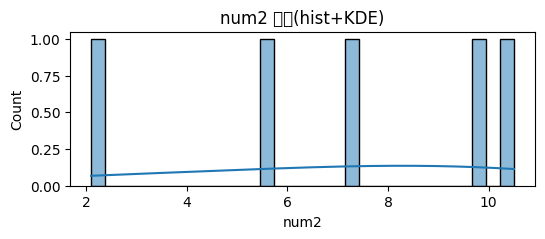

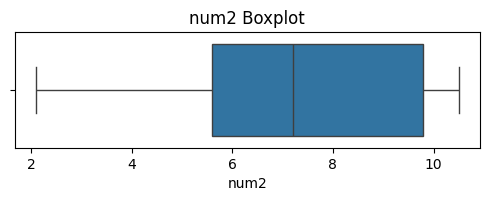

이상치 개수: 0 (범위 -0.70 ~ 16.10)
dtype: float64
추정 단위: num2
→ |skew|=0.44 < 1.0: 변환 불필요


In [118]:
# --- 연속형 수치 컬럼 분석 ---
for col in num_cols:
    print(f"\n=== [Numeric] {col} ===")
    
    # 기본 통계
    check_describe(col)
    check_skew(col)  
    check_kurtosis(col)  

    # 결측치 
    check_missing_values(col)
    
    #고유값
    check_unique_values(col)
 
    # 분포 시각화
    show_hist_kde_plot(col)    
    
    show_box_plot(col)

    # 이상치 탐지 (IQR 방식)
    detect_outliers_by_IQR(col)
    
    # 데이터 타입·단위
    check_numberic_type_unit(col)
    
    # 변환 필요성 판단 (skew 기준)
    decide_trans_by_skew(col)
  

In [119]:
def get_unique_values_count_with_NAN(column) :
    return df[col].value_counts(dropna=False)


In [120]:
def check_top_10_categories(column) :
    counts = get_unique_values_count_with_NAN(column)
    print("상위 10개 범주:\n", counts.head(10))

In [121]:
def show_count_plot(column) :
    counts = get_unique_values_count_with_NAN(column)

    plt.figure(figsize=(6,2))
    sns.countplot(y=column, data=df, order=counts.index[:10])
    plt.title(f"{col} Countplot (상위10)")
    plt.show()

In [122]:
def check_category_type(column) :
    print(f"dtype: {df[column].dtype}")

In [123]:
def decide_incoding_by_colum_size(column) : 
    # 인코딩 필요성
    counts = get_unique_values_count_with_NAN(column)
    
    if counts.size > 10:
        print("→ 범주가 많음: Label/One-Hot 인코딩 전 빈도 기준 병합 고려")
    else:
        print("→ 범주 적음: 직접 One-Hot 또는 Label 인코딩 가능")


=== [Category] city ===
결측치 개수: 0
고유값 개수: 4
→ 값 분포:
 city
Gwangju          1
Gyeonggi         2
Gyeongsangbuk    1
Seoul            1
Name: count, dtype: int64
상위 10개 범주:
 city
Gyeonggi         2
Seoul            1
Gyeongsangbuk    1
Gwangju          1
Name: count, dtype: int64


f:\examination\workspace\associate.aice\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
f:\examination\workspace\associate.aice\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


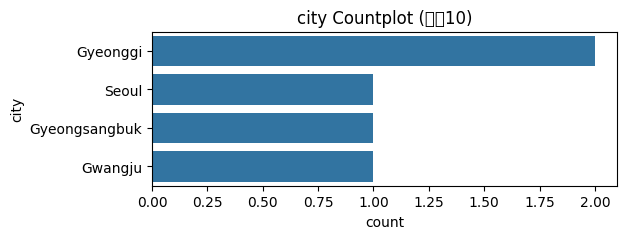

dtype: object
→ 범주 적음: 직접 One-Hot 또는 Label 인코딩 가능

=== [Category] color ===
결측치 개수: 0
고유값 개수: 3
→ 값 분포:
 color
blue     2
green    1
red      2
Name: count, dtype: int64
상위 10개 범주:
 color
blue     2
red      2
green    1
Name: count, dtype: int64


f:\examination\workspace\associate.aice\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
f:\examination\workspace\associate.aice\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


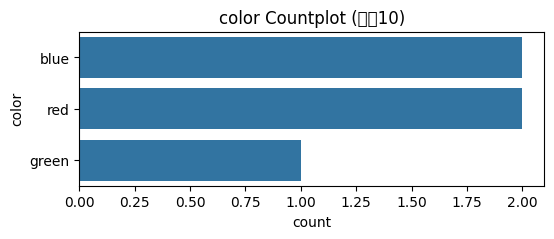

dtype: category
→ 범주 적음: 직접 One-Hot 또는 Label 인코딩 가능


In [124]:
for col in cat_cols:
    print(f"\n=== [Category] {col} ===")

    # 결측치 
    check_missing_values(col)
    
    #고유값
    check_unique_values(col)
    
    # 결측 포함 상위 빈도
    check_top_10_categories(col)
    
    # 분포 시각화
    show_count_plot(col)
    
    # dtype 확인
    check_category_type(col)
    
    decide_incoding_by_colum_size(col)